In [41]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm.keras import TqdmCallback

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical 

sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_ABC-SN/")
from plot_data import *
from process_data import *

In [42]:
import tensorflow as tf



In [43]:
file = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/full_preprocessed_dataframe.parquet"
master_df = pd.read_parquet(file)

In [44]:
types, counts = np.unique(master_df.sn_type.values, return_counts = True)
for i in range(len(types)):
    print(types[i], " : ", counts[i])

CaRT  :  52
II  :  1819
IIb  :  542
IIn  :  880
Ia  :  8074
Iap  :  263
Ib  :  262
Ic  :  193
SL  :  1262
TDE  :  96


In [143]:
types, counts = np.unique(master_df.Mill_type.values, return_counts = True)
for i in range(len(types)):
    print(types[i], " : ", counts[i])

0.0  :  8337
1.0  :  997
2.0  :  2699
3.0  :  1262
4.0  :  148


In [80]:
# Choose the ones with ABC-SN labels only 
master_index = ~np.isnan(master_df.ABC_type.values)
other_index = np.isnan(master_df.ABC_type.values)
df = master_df[master_index]
df = df.reset_index(drop=True)

# creating y array to use for stratification
y = master_df["ABC_type"].values[master_index]
index = master_df.index.values[master_index]

In [110]:
mill_y = master_df.Mill_type.values

In [81]:
train_index, test_index = train_test_split(index, test_size = 0.3, random_state = 7, stratify = y)

In [111]:
train_index_other, test_index_other = train_test_split(master_df.index.values[other_index], 
                                                       test_size = 0.3, random_state = 7, 
                                                       stratify = mill_y[other_index])

In [154]:
master_df.Mill_type[master_df.sn_type == "IIb"]  

111      1.0
112      1.0
113      1.0
114      1.0
115      1.0
        ... 
12938    1.0
12939    1.0
12940    1.0
12941    1.0
12942    1.0
Name: Mill_type, Length: 542, dtype: float64

In [82]:
data = dp.extract_dataframe(master_df)

wvl = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
df_metadata = data[5]  # Sub-dataframe containing only the metadata
fluxes0 = data[6]  # Only the flux values in a numpy array

In [104]:
# one hot encode the y values 
y_ohe = to_categorical(y, num_classes=10)
full_ohe = np.zeros((len(master_df), 10), dtype=int)
full_ohe[master_index]= y_ohe

In [124]:
full_test_index = np.concat([test_index_other, test_index])

In [125]:
X = fluxes0.copy()
X = X.reshape(X.shape[0],1,X.shape[1])

X_train = X[train_index]
X_test = X[full_test_index]

y_train = full_ohe[train_index]
y_test =  full_ohe[full_test_index]

In [126]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7807, 1, 139), (4033, 1, 139), (7807, 10), (4033, 10))

In [128]:
df_test = master_df.iloc[full_test_index].copy()
df_test.ABC_type.unique()

array([nan,  0.,  6.,  1.,  9.,  4.,  7.])

## Loading ABC-SN to make predictions


In [145]:
# Loading model 
abcsn = keras.models.load_model("/lustre/lrspec/users/4301/Milligan_ABC-SN/model_results/finetuning800_weighted_loss.keras", compile=False)
# abcsn = keras.models.load_model("/lustre/lrspec/users/4301/Milligan_ABC-SN/ABCSN_finetuning100.keras", compile=False)

## Results

In [146]:

# predict type
P = abcsn.predict(X_test, verbose=0)
P_argmax = np.argmax(P, axis=1)

df_test["Pred_ABC_ID"] = P_argmax

# get type as milligan ID
ABC_to_Mill = get_ABC_to_Mill_dict()
P_Mill = np.array([ABC_to_Mill[i] for i in P_argmax])
df_test["Pred_Mill_ID"] = P_Mill


2026-07-21 18:48:16.898640: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


### Checking various types

In [147]:
# Predicted ABC id counts
np.unique(P_argmax, return_counts=True)

(array([0, 1, 4, 6, 7, 9]), array([1994,  260,  419,  428,  201,  731]))

In [148]:
# true ABC ids
Y_ABC_IDs = df_test.ABC_type.values
np.unique(Y_ABC_IDs, return_counts=True)

(array([ 0.,  1.,  4.,  6.,  7.,  9., nan]),
 array([2422,   79,   78,  163,   58,  546,  687]))

In [149]:
np.unique(P_Mill, return_counts=True)

(array([0, 1, 2]), array([2254, 1048,  731]))

# Looking at the results of prediction with ABCSN labels

In [134]:

cr = (classification_report(
    Y_ABC_IDs,
    P_argmax,
    labels=list(ABC_subtype_id_to_str.keys()),
    target_names=list(ABC_subtype_id_to_str.values())
    ))

print(cr)


/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/sklearn/externals/array_api_compat/numpy/_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input y_true contains NaN.

In [135]:
ABC_ID_dict = get_ABC_ID_dict()
labels = [ABC_ID_dict[id] for id in np.unique(Y_ABC_IDs)]


cm = confusion_matrix(df_test.ABC_type.values, 
                      df_test.Pred_ABC_ID.values,
                     labels = np.unique(Y_ABC_IDs))
plot = plot_cm(cm, labels, 
               title = "full confusion matrix for ABC labels \n normalized by row",
              normalize = True)

KeyError: np.float64(nan)

## look at various normalizations

In [136]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(df_test.ABC_type.values, 
                          df_test.Pred_ABC_ID.values, 
                          labels=np.unique(Y_ABC_IDs)[:],
                          normalize=normalizations[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title(titles[i])
    plt.show()

/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/sklearn/externals/array_api_compat/numpy/_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input y_true contains NaN.

## Looking at close and bright SN objects

In [60]:

brighter_SN_index = df_test.host_mag > df_test.SN_mag + 1
small_z_index = df_test.redshift < 0.05
print(sum(small_z_index & brighter_SN_index))
bright_close_index = small_z_index & brighter_SN_index

bright_close_SN_df = df_test[bright_close_index].copy()

41


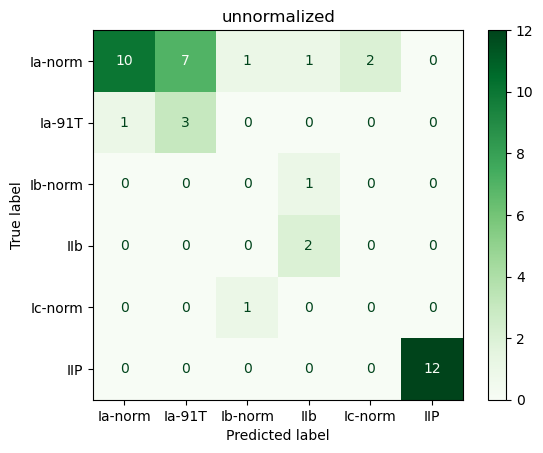

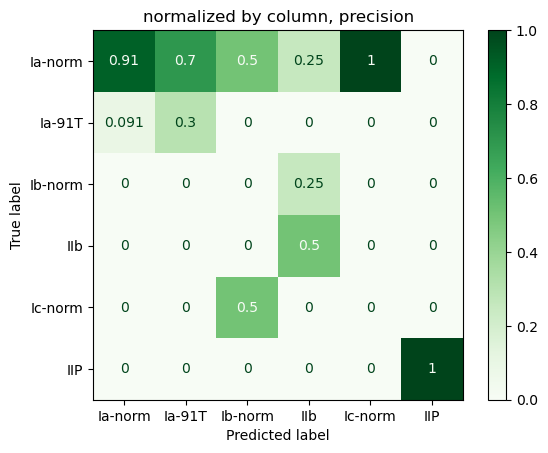

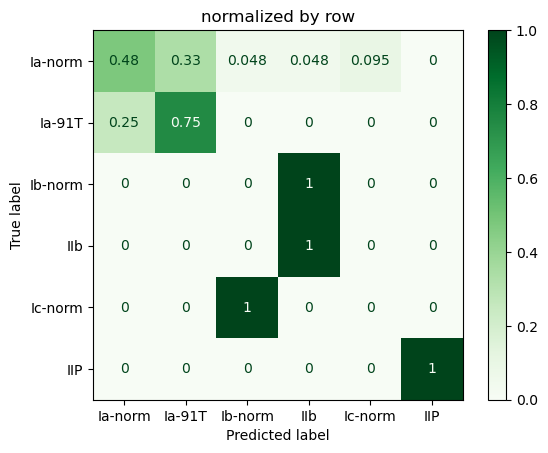

In [61]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(bright_close_SN_df.ABC_type.values, 
                          bright_close_SN_df.Pred_ABC_ID.values, 
                          labels=np.unique(Y_ABC_IDs),
                          normalize=normalizations[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)
    disp.plot(cmap='Greens')
    plt.title(titles[i])
    plt.show()

## Using Milligan Labels

In [165]:
Mill_types_to_int.values()

dict_values(['Ia', 'Ib & Ic', 'II', 'SLSN', 'Non-SN', 'other'])

In [158]:
df_test.Pred_Mill_ID

10225    1
8970     1
6497     2
10206    1
12554    1
        ..
6276     2
2853     0
3443     0
422      0
729      1
Name: Pred_Mill_ID, Length: 4033, dtype: int64

In [167]:

cr = classification_report(
    df_test.Mill_type,
    df_test.Pred_Mill_ID,
    labels=list(Mill_types_to_int.keys()),
    target_names=list(Mill_types_to_int.values())
)

print(cr)

              precision    recall  f1-score   support

          Ia       0.92      0.83      0.88      2501
     Ib & Ic       0.20      0.71      0.31       299
          II       0.77      0.69      0.73       810
        SLSN       0.00      0.00      0.00       379
      Non-SN       0.00      0.00      0.00        44
       other       0.00      0.00      0.00         0

    accuracy                           0.71      4033
   macro avg       0.32      0.37      0.32      4033
weighted avg       0.74      0.71      0.71      4033



/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.ca

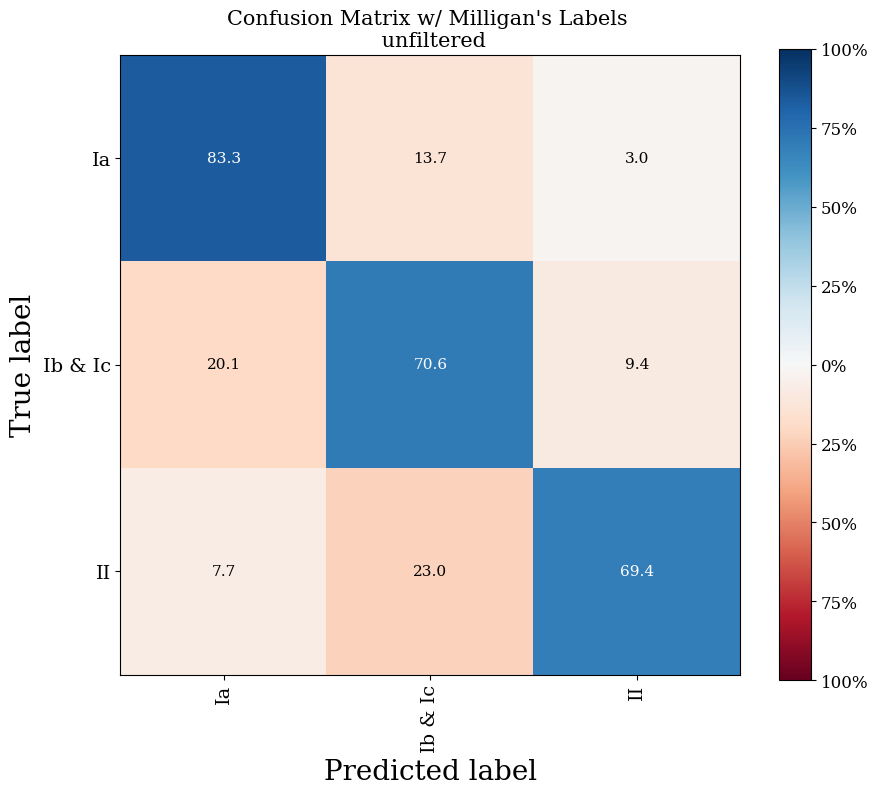

In [150]:

cm_mill = confusion_matrix(df_test.Mill_type, df_test.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n unfiltered")

In [151]:
cm_mill

array([[2084,  342,   75,    0,    0,    0],
       [  60,  211,   28,    0,    0,    0],
       [  62,  186,  562,    0,    0,    0],
       [  41,  280,   58,    0,    0,    0],
       [   7,   29,    8,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0]])

In [139]:
list(Mill_types_to_int.values())

['Ia', 'Ib & Ic', 'II', 'SLSN', 'Non-SN', 'other']

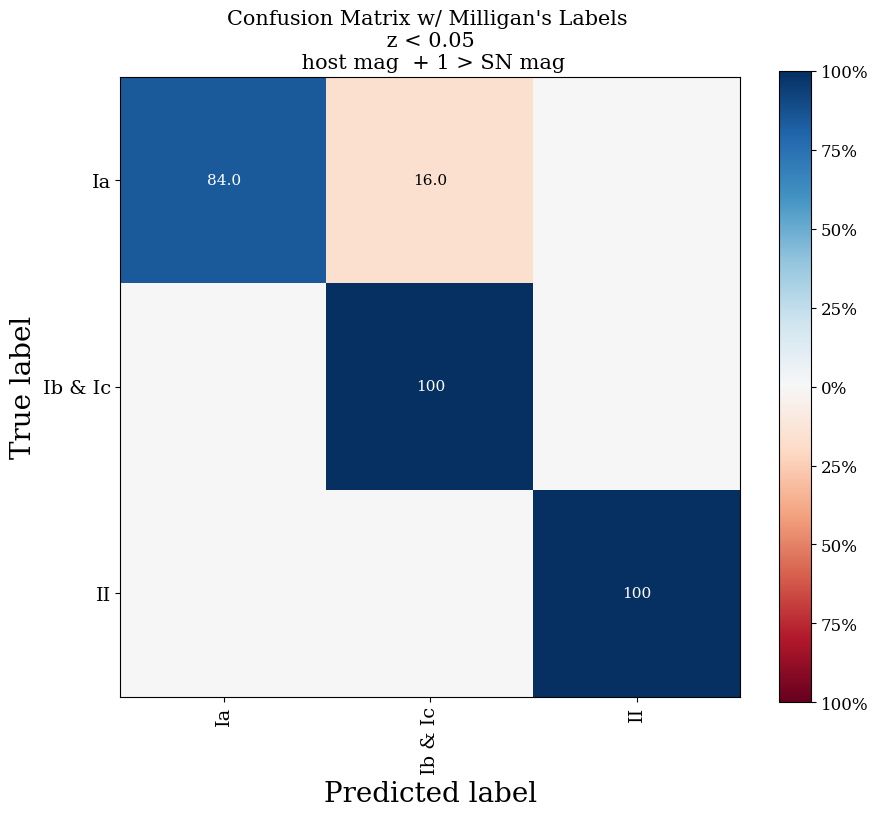

In [140]:
cm_mill = confusion_matrix(bright_close_SN_df.Mill_type, bright_close_SN_df.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n z < 0.05 \n host mag  + 1 > SN mag")

# Looking at classification spectra ... not particulary useful

/tmp/ipykernel_25251/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_25251/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_25251/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_25251/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")


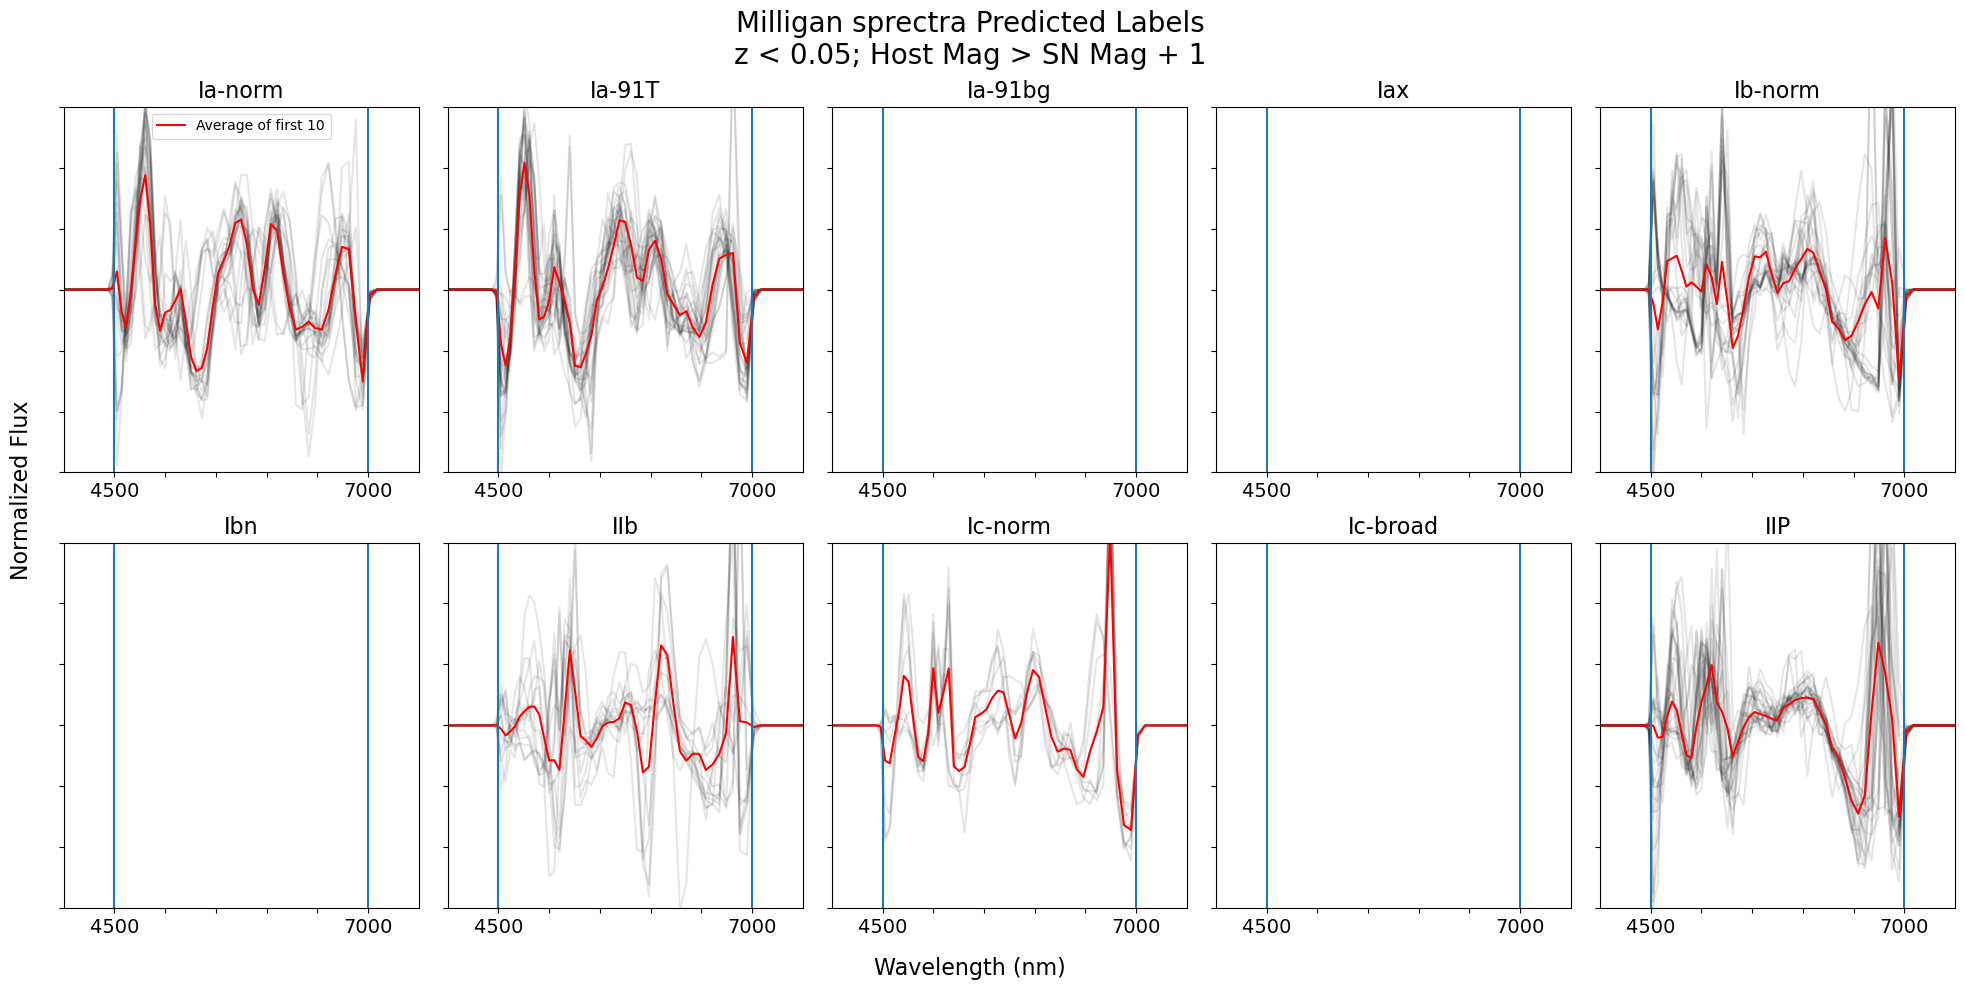

In [66]:
types = list(ABC_subtype_id_to_str.keys())
types_titles = list(ABC_subtype_id_to_str.values())
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
brighter_SN_index = df_test.host_mag > df_test.SN_mag +1
small_z_index = df_test.redshift < 0.05
close_bright_df = df_test[small_z_index] #df[brighter_SN_index & small_z_index]
num_wvl = 139
flux_start, flux_stop = 59, 103


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = close_bright_df[close_bright_df.Pred_ABC_ID == sn_type]
    
    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += fluxes0[i]
        if n < 25:
            ax.plot(wvl, fluxes0[i], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "r", label="Average of first 10")
    ax.set_title(f"{types_titles[j]}", fontsize = 16)
    ax.set_ylim(-3, 3)
    ax.set_xlim(4000,7500)
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels(['', '', '', '', '', ''])
    ax.set_yticks([-3,-2,-1, 0, 1,2,3])
    ax.set_yticklabels(["", "", " ", " ", "", "", "" ])
    if j == 0:
        ax.legend()
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels([4500, '', '', '', '', 7000], fontsize = 14)

    ax.axvline(4500)
    ax.axvline(7000)

fig.suptitle("Milligan sprectra Predicted Labels\nz < 0.05; Host Mag > SN Mag + 1", fontsize =20)

fig.supxlabel("Wavelength (nm)", fontsize = 16)
fig.supylabel("Normalized Flux\n", fontsize = 16)


plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
